# 02 — Error Analysis: Baseline vs Physics-Augmented

Loads both checkpoints, runs inference on the held-out test set, and compares:
- Confusion matrices
- Per-class F1 scores
- Class imbalance vs improvement scatter
- Failure cases fixed by augmentation

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader
from PIL import Image

from training.dataset import SolarModuleDataset, load_splits
from training.model import build_model

CKPT_DIR   = ROOT / "checkpoints"
FIGURES_DIR = Path(".")   # save relative to notebook location

device = (
    torch.device("cuda") if torch.cuda.is_available()
    else torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cpu")
)
print(f"Device: {device}")

Device: mps


In [2]:
splits   = load_splits()
test_df  = splits["test"]
train_df = splits["train"]
classes  = sorted(test_df["label"].unique().tolist())
n_cls    = len(classes)
print(f"{n_cls} classes, {len(test_df)} test images")

12 classes, 3000 test images


In [3]:
def run_inference(ckpt_path: Path) -> tuple[list[int], list[int]]:
    """Load checkpoint, run on test set, return (preds, true_labels)."""
    model = build_model(n_cls, pretrained=False).to(device)
    model.load_state_dict(
        torch.load(ckpt_path, map_location=device, weights_only=True)
    )
    model.eval()

    loader = DataLoader(
        SolarModuleDataset(test_df, classes, split="val"),
        batch_size=64, shuffle=False, num_workers=0,
    )
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            preds = model(imgs.to(device)).argmax(1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.tolist())
    return all_preds, all_labels


print("Running baseline ...")
base_preds,  base_labels  = run_inference(CKPT_DIR / "baseline_best.pt")
print("Running physics-augmented ...")
aug_preds,   aug_labels   = run_inference(CKPT_DIR / "physics-augmented_best.pt")
print("Done.")

Running baseline ...


Running physics-augmented ...


Done.


## Confusion matrices

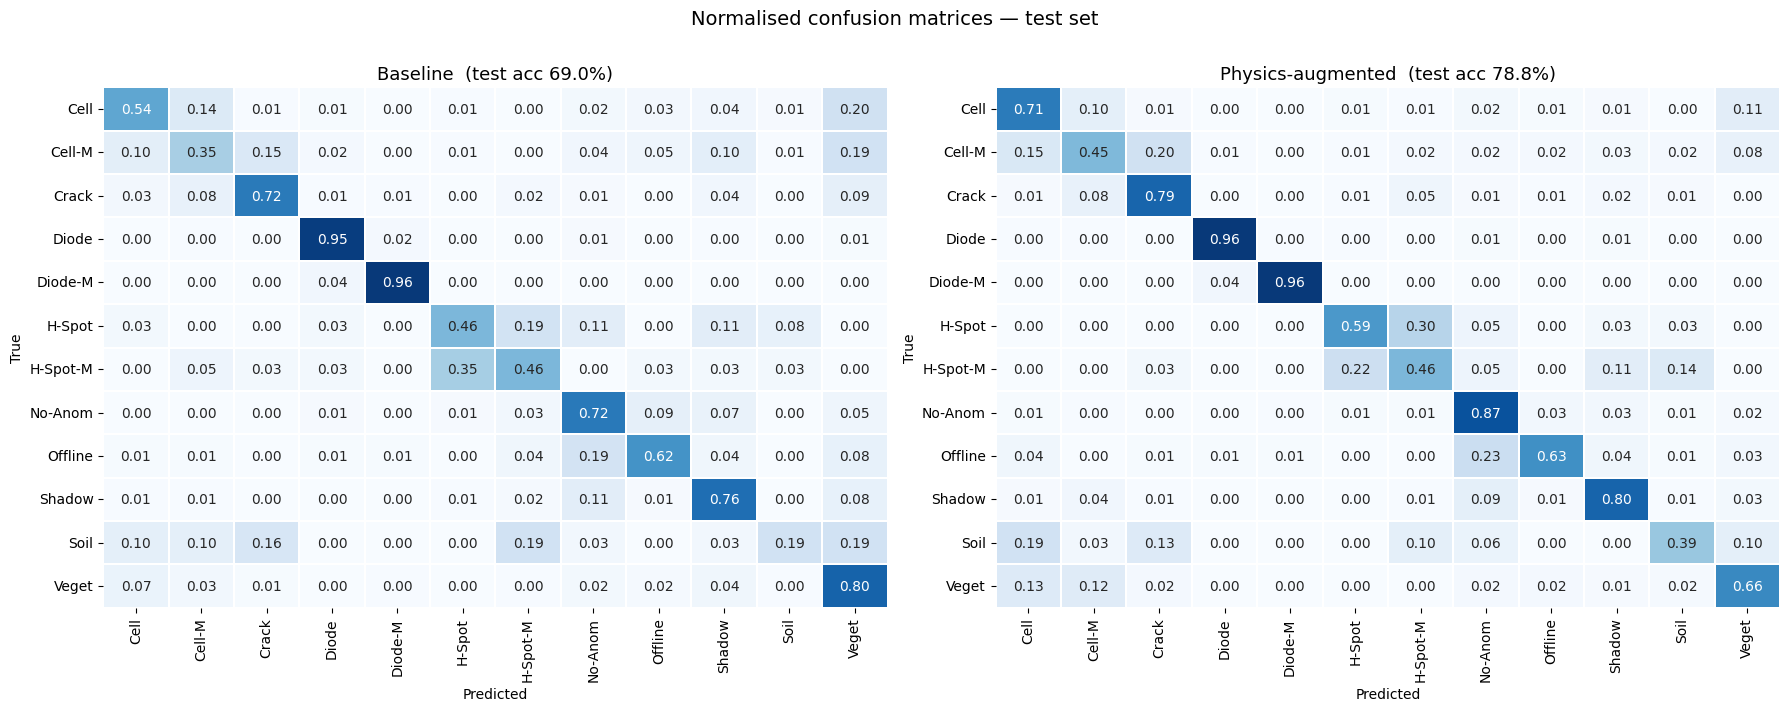

In [4]:
short_names = [
    "Cell", "Cell-M", "Crack", "Diode", "Diode-M",
    "H-Spot", "H-Spot-M", "No-Anom", "Offline",
    "Shadow", "Soil", "Veget",
]

def norm_cm(preds, labels):
    cm = confusion_matrix(labels, preds, labels=list(range(n_cls)))
    return cm.astype(float) / cm.sum(axis=1, keepdims=True)


cm_base = norm_cm(base_preds, base_labels)
cm_aug  = norm_cm(aug_preds,  aug_labels)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
kw = dict(annot=True, fmt=".2f", cmap="Blues", linewidths=0.3,
          xticklabels=short_names, yticklabels=short_names,
          vmin=0, vmax=1, cbar=False)

sns.heatmap(cm_base, ax=axes[0], **kw)
axes[0].set_title("Baseline  (test acc 69.0%)", fontsize=13)
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

sns.heatmap(cm_aug, ax=axes[1], **kw)
axes[1].set_title("Physics-augmented  (test acc 78.8%)", fontsize=13)
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

plt.suptitle("Normalised confusion matrices — test set", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## Per-class F1 comparison

In [5]:
def f1_per_class(preds, labels):
    rep = classification_report(
        labels, preds, target_names=classes, output_dict=True, zero_division=0
    )
    return pd.Series({c: rep[c]["f1-score"] for c in classes})


f1_base = f1_per_class(base_preds, base_labels)
f1_aug  = f1_per_class(aug_preds,  aug_labels)
delta   = f1_aug - f1_base

df_f1 = pd.DataFrame({"Baseline": f1_base, "Augmented": f1_aug, "Delta": delta})
df_f1 = df_f1.sort_values("Baseline")
print(df_f1.to_string(float_format="{:.3f}".format))

                Baseline  Augmented  Delta
Soiling            0.250      0.316  0.066
Hot-Spot-Multi     0.260      0.354  0.095
Hot-Spot           0.378      0.512  0.134
Cell-Multi         0.407      0.479  0.072
Offline-Module     0.424      0.589  0.164
Shadowing          0.548      0.706  0.158
Vegetation         0.603      0.661  0.058
Cell               0.625      0.701  0.075
Cracking           0.716      0.725  0.009
Diode-Multi        0.806      0.847  0.041
No-Anomaly         0.815      0.909  0.094
Diode              0.910      0.964  0.054


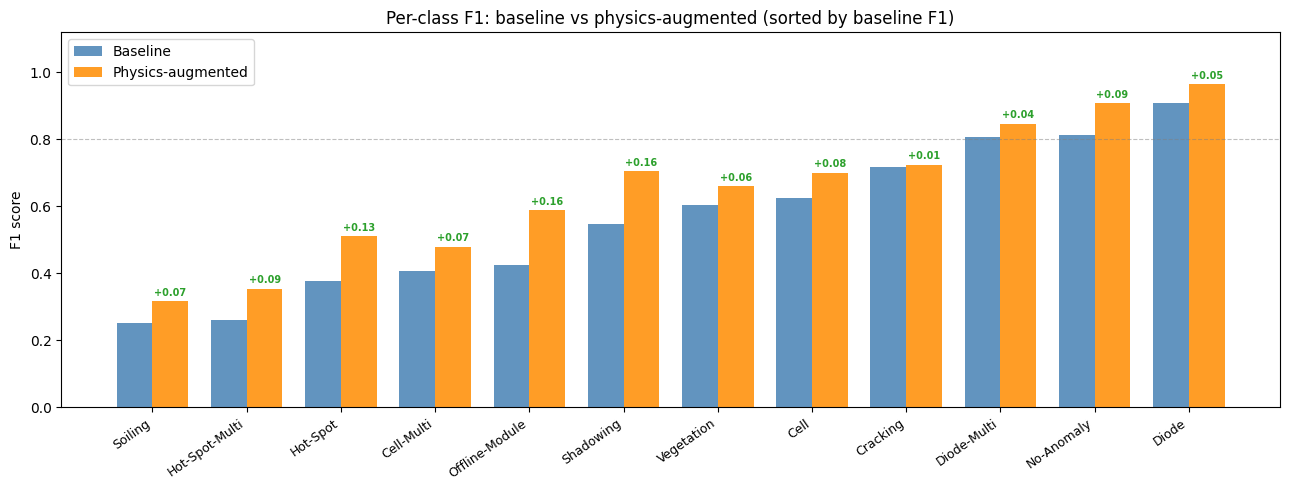

In [6]:
x = np.arange(n_cls)
w = 0.38

fig, ax = plt.subplots(figsize=(13, 5))
bars_b = ax.bar(x - w/2, df_f1["Baseline"], w, label="Baseline",
                color="steelblue", alpha=0.85)
bars_a = ax.bar(x + w/2, df_f1["Augmented"], w, label="Physics-augmented",
                color="darkorange", alpha=0.85)

# Annotate delta on top of augmented bar
for xi, (_, row) in zip(x, df_f1.iterrows()):
    d = row["Delta"]
    color = "#2ca02c" if d > 0 else "#d62728"
    ax.text(xi + w/2, row["Augmented"] + 0.01, f"{d:+.2f}",
            ha="center", va="bottom", fontsize=7, color=color, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(df_f1.index, rotation=35, ha="right", fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_ylabel("F1 score")
ax.set_title("Per-class F1: baseline vs physics-augmented (sorted by baseline F1)")
ax.legend()
ax.axhline(0.8, color="grey", lw=0.8, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "per_class_f1.png", dpi=150, bbox_inches="tight")
plt.show()

## Class imbalance vs F1 improvement

Do the rarest classes benefit most from augmentation?

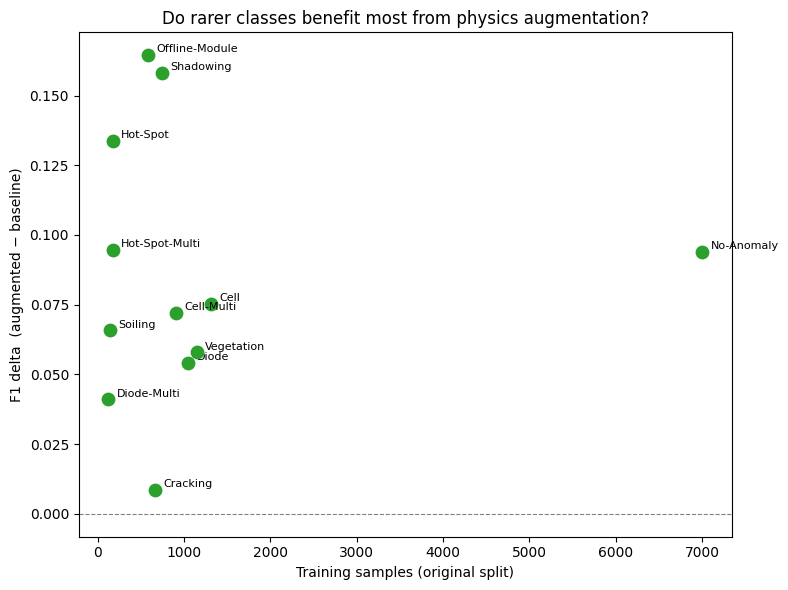

In [7]:
train_counts = train_df["label"].value_counts()

fig, ax = plt.subplots(figsize=(8, 6))
for cls in classes:
    cnt = train_counts.get(cls, 0)
    d   = delta[cls]
    ax.scatter(cnt, d, s=80, zorder=3,
               color=("#2ca02c" if d > 0 else "#d62728"))
    ax.annotate(cls, (cnt, d), textcoords="offset points",
                xytext=(6, 2), fontsize=8)

ax.axhline(0, color="grey", lw=0.8, linestyle="--")
ax.set_xlabel("Training samples (original split)")
ax.set_ylabel("F1 delta  (augmented − baseline)")
ax.set_title("Do rarer classes benefit most from physics augmentation?")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "imbalance_vs_improvement.png", dpi=150, bbox_inches="tight")
plt.show()

## Failure cases fixed by augmentation

Images the baseline got wrong that the augmented model got right, for the classes that improved most.

Most improved classes: ['Offline-Module', 'Shadowing', 'Hot-Spot']


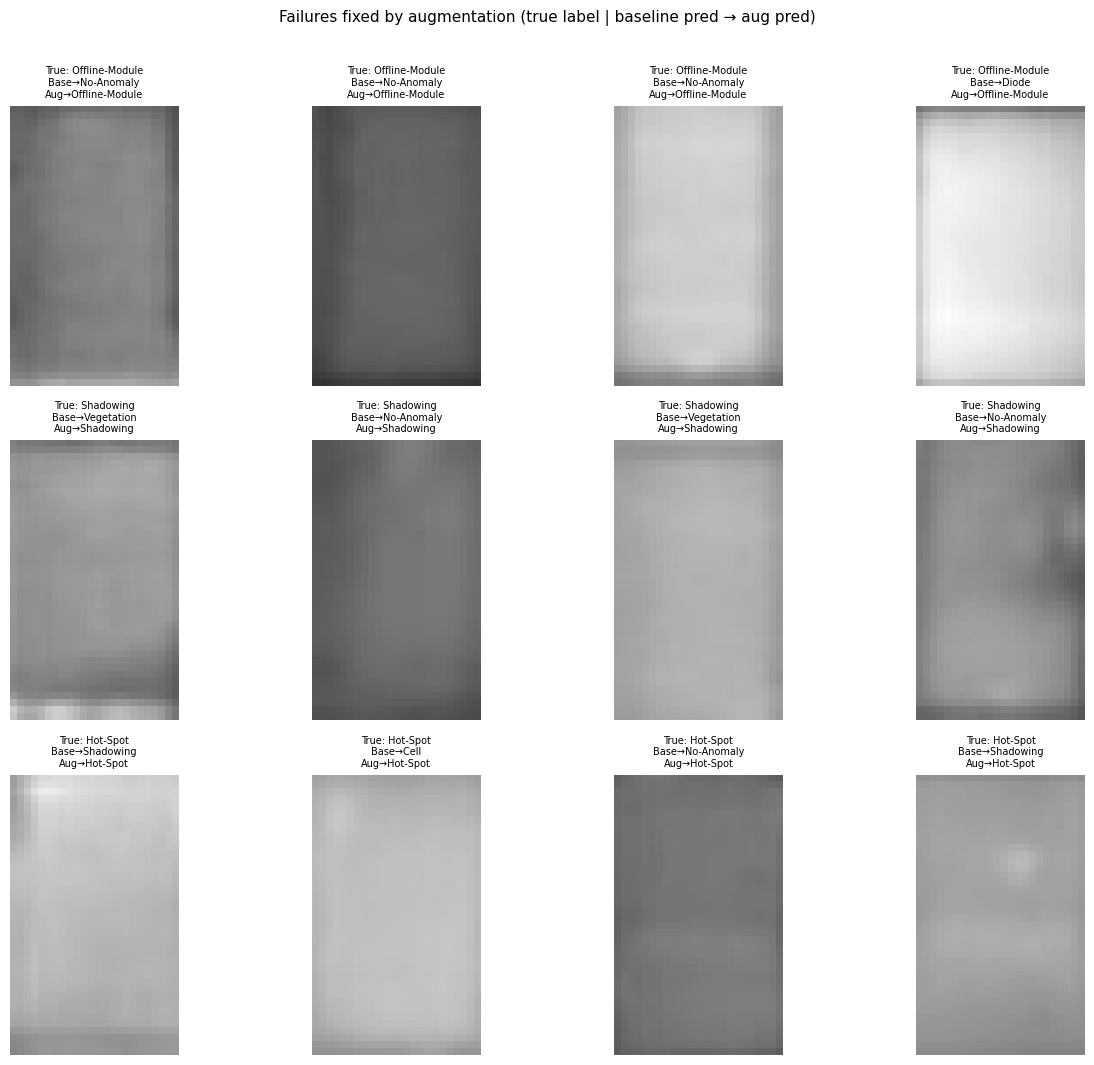

In [8]:
# Find top-3 most improved classes
top_improved = delta.sort_values(ascending=False).head(3).index.tolist()
print("Most improved classes:", top_improved)

label_arr     = np.array(base_labels)          # same for both (same test set)
base_pred_arr = np.array(base_preds)
aug_pred_arr  = np.array(aug_preds)

# Fixed: baseline wrong, augmented correct
fixed_mask = (base_pred_arr != label_arr) & (aug_pred_arr == label_arr)

fig, axes = plt.subplots(len(top_improved), 4, figsize=(13, 3.5 * len(top_improved)))
if len(top_improved) == 1:
    axes = axes[np.newaxis, :]

for row_idx, cls in enumerate(top_improved):
    cls_idx = classes.index(cls)
    idxs = np.where(fixed_mask & (label_arr == cls_idx))[0][:4]

    for col_idx in range(4):
        ax = axes[row_idx, col_idx]
        if col_idx < len(idxs):
            i = idxs[col_idx]
            img = Image.open(test_df.iloc[i]["path"]).convert("RGB")
            ax.imshow(img, cmap="inferno")
            ax.set_title(
                f"True: {cls}\n"
                f"Base→{classes[base_pred_arr[i]]}\n"
                f"Aug→{classes[aug_pred_arr[i]]}",
                fontsize=7,
            )
        ax.axis("off")

plt.suptitle("Failures fixed by augmentation (true label | baseline pred → aug pred)",
             y=1.01, fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fixed_failures.png", dpi=120, bbox_inches="tight")
plt.show()

## Summary table

In [9]:
base_acc = np.mean(np.array(base_preds) == np.array(base_labels))
aug_acc  = np.mean(np.array(aug_preds)  == np.array(aug_labels))

print(f"{'Model':<22} {'Accuracy':>10}  {'Macro F1':>10}")
print("-" * 46)
for name, preds, labels, acc in [
    ("Baseline",          base_preds, base_labels, base_acc),
    ("Physics-augmented", aug_preds,  aug_labels,  aug_acc),
]:
    rep = classification_report(labels, preds, output_dict=True, zero_division=0)
    print(f"{name:<22} {acc:>10.4f}  {rep['macro avg']['f1-score']:>10.4f}")

print(f"\n{'Delta':>22} {aug_acc - base_acc:>+10.4f}  "
      f"{classification_report(aug_labels, aug_preds, output_dict=True, zero_division=0)['macro avg']['f1-score'] - classification_report(base_labels, base_preds, output_dict=True, zero_division=0)['macro avg']['f1-score']:>+10.4f}")

Model                    Accuracy    Macro F1
----------------------------------------------
Baseline                   0.6903      0.5619
Physics-augmented          0.7883      0.6469

                 Delta    +0.0980     +0.0850
